**TASK-1**: Implement a linear regression model to predict the prices of houses based on their square footage and the number of bedrooms and bathrooms.

In [ ]:
import numpy as np
import pandas as pd

# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_houses = 100

square_footage = np.random.randint(1000, 5000, num_houses)
num_bedrooms = np.random.randint(2, 6, num_houses)
num_bathrooms = np.random.randint(1, 4, num_houses)

# Generate prices with a linear relationship to features and some noise
price = (square_footage * 100) + (num_bedrooms * 20000) + (num_bathrooms * 15000) + np.random.normal(0, 50000, num_houses)
price = np.maximum(price, 100000) # Ensure prices are not too low

df = pd.DataFrame({
    'square_footage': square_footage,
    'num_bedrooms': num_bedrooms,
    'num_bathrooms': num_bathrooms,
    'price': price
})

print("Synthetic dataset generated successfully.")

Synthetic dataset generated successfully.


In [ ]:
# Display the first 5 rows of the dataset
display(df.head())

In [ ]:
display(df.head())

,square_footage,num_bedrooms,num_bathrooms,price
0,4174,3,3,558306.413991
1,4507,3,1,478126.412468
2,1860,5,1,274191.994991
3,2294,3,2,374226.442825
4,2130,3,1,309400.642049


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['square_footage', 'num_bedrooms', 'num_bathrooms']]
y = df['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 80 samples
Testing set size: 20 samples


### Train the Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Evaluate the Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 44,633.65
Mean Squared Error (MSE): 2,772,250,576.90
Root Mean Squared Error (RMSE): 52,652.17
R-squared (R2): 0.8389


### Visualize Predicted vs. Actual Prices

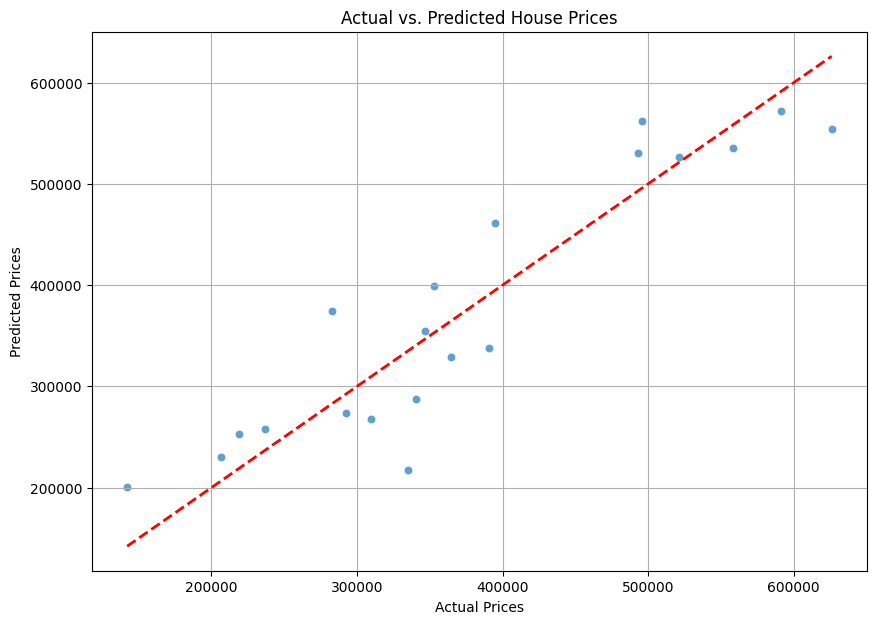

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted prices
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

# Add a line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.grid(True)
plt.show()